In [25]:
import geopandas as gpd
from pathlib import Path
from pyproj import Transformer
import numpy as np
from scipy import interpolate
from typing import Tuple, Union, Optional
from matplotlib import pyplot as plt

import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import calculate_default_transform, reproject
from rasterio.crs import CRS
from rasterio.transform import Affine, from_bounds
from rasterio.warp import Resampling, reproject
from typing import Dict, Any, Union
from pathlib import Path
import numpy as np

import opera_utils

import venti
from venti.log import get_logger
from venti.models import plate_motion, load_itrf

logger = get_logger("venti", enable_file_logging=False)

In [26]:
def make_point_grid(gdf: gpd.GeoDataFrame, 
                   cell_size: float = 50000, 
                   target_crs: str = "EPSG:4326") -> Tuple[np.ndarray, np.ndarray]:
    """
    Create a regular point grid within a polygon GeoDataFrame.
    
    Parameters
    ----------
    gdf : GeoDataFrame
        Input polygon(s), assumed to be in EPSG:4326.
    cell_size : float, optional
        Spacing between points in meters (default: 50,000 = 50 km).
    target_crs : str, optional
        CRS for output grid (default: "EPSG:4326").
    
    Returns
    -------
    x : np.ndarray
        X coordinates of grid points (longitude if EPSG:4326).
    y : np.ndarray
        Y coordinates of grid points (latitude if EPSG:4326).
        
    Raises
    ------
    ValueError
        If input GeoDataFrame is empty or invalid.
    """
    if gdf.empty:
        raise ValueError("Input GeoDataFrame is empty")
    
    if gdf.crs is None:
        logger.warning("No CRS defined for input GeoDataFrame, assuming EPSG:4326")
        gdf = gdf.set_crs("EPSG:4326")
    
    try:
        # Project polygon to UTM for accurate meter-based calculations
        utm_crs = gdf.estimate_utm_crs()
        gdf_proj = gdf.to_crs(utm_crs)
        logger.info(f"Projected to {utm_crs} for grid generation")
        
        # Get bounds
        minx, miny, maxx, maxy = gdf_proj.total_bounds
        logger.info(f"Bounds: {minx:.0f}, {miny:.0f}, {maxx:.0f}, {maxy:.0f}")
        
        # Calculate grid dimensions
        width = max(1, int(np.rint((maxx - minx) / cell_size)))
        length = max(1, int(np.rint((maxy - miny) / cell_size)))
        logger.info(f"Grid dimensions: {width} x {length} points")
        
        # Generate grid coordinates
        gridy, gridx = np.mgrid[maxy:miny:length*1j, minx:maxx:width*1j]
        
        # Transform back to target CRS
        transformer = Transformer.from_crs(utm_crs, target_crs, always_xy=True)
        x, y = transformer.transform(gridx, gridy)
        
        logger.info(f"Generated grid with {x.size} points")
        return x, y
        
    except Exception as e:
        logger.error(f"Error generating grid: {e}")
        raise


def get_model_per_frame(frame_id: int,
                        output: Union[str | Path] = 'output', 
                        plate: str = "NOAM", 
                        itrf: Union[int, str] = 2014, 
                        gia: Optional[str] = None,
                        resampling_mode: Resampling = Resampling.bilinear) -> Tuple[np.ndarray, np.ndarray]:
    # DISP frame database path 
    data_path = Path(venti.__path__[0]).parents[1]
    
    # Set output dir 
    output_dir = Path(output)
    output_dir.mkdir(exist_ok=True)

    # Output name
    output_name = output_dir / f"frame_{frame_id}_{plate}_ITRF{itrf}_rates.tif"

    # Validate inputs
    if itrf not in [2014, 2020]:
        raise ValueError(f"ITRF year must be 2014 or 2020, got {itrf}")
    
    # Check for required data files
    frame_file = data_path / "data/opera_disp_frame.geojson"
    if not frame_file.exists():
        raise FileNotFoundError(f"DISP frame database not found: {frame_file}")
    
    # Load DISP frame database
    logger.info(f"Loading DISP frame database")
    disp_frame_db = opera_utils.get_frame_geodataframe()

    # Select requested frame
    selected_frame = disp_frame_db[disp_frame_db.index == frame_id]
    if selected_frame.empty:
        available_fids = disp_frame_db.index.unique()
        raise ValueError(f"Frame ID {frame_id} not found. "
                         f"Available IDs: {available_fids}")
    logger.info(f"Selected frame {frame_id}")

    # Determine UTM CRS for the frame
    utm_crs = selected_frame.estimate_utm_crs()
    selected_frame_utm = selected_frame.to_crs(utm_crs)
    minx, miny, maxx, maxy = selected_frame_utm.total_bounds
    xs = np.arange(minx, maxx, 30)
    ys = np.arange(maxy, miny, -30)
    dst_transform = Affine(30, 0, minx, 0, -30, maxy)
    target_height, target_width = len(ys), len(xs)

    # Load ITRF PMM
    itrf_pmm = load_itrf.load_itrf_pmm(date=itrf)
    pmm = itrf_pmm[itrf_pmm.plate == plate]

    if pmm.empty:
        available_plates = itrf_pmm['plate'].unique()
        raise ValueError(f"Plate '{plate}' not found. Available plates: {available_plates}")
    
    # Generate coarse grid for plate motion (10km spacing)
    grid_lons, grid_lats = make_point_grid(selected_frame, cell_size=10e3)
    grid_length, grid_width = grid_lons.shape
    src_transform = from_bounds(*selected_frame.total_bounds,
                                width=grid_width, height=grid_length)
    src_crs = selected_frame.crs

    # Model plate horizontal velocities
    logger.info("Modeling plate velocities")
    pmm_vel = plate_motion.model_plate_velocities(
        grid_lons.ravel(), grid_lats.ravel(), 
        pmm.omega_x.iloc[0], pmm.omega_y.iloc[0], pmm.omega_z.iloc[0]
    )
    pmm_ve = pmm_vel[:, 0].reshape((grid_length, grid_width)) # East-West
    pmm_vn = pmm_vel[:, 1].reshape((grid_length, grid_width)) # North-South

    # Interpolate and repoject plate motion to DISP grid
    atr = {"rows":target_height, "cols":target_width}

    with rasterio.open(
            output_name, "w",
            height=atr["rows"], width=atr["cols"],
            count=2, dtype="float32", crs=utm_crs, transform=dst_transform,
            nodata=np.nan,
            compress='lzw', tiled=True, blockxsize=512, blockysize=512,
            predictor=2, interleave='band',
    ) as dst:
        dst.set_band_description(1, "North-South (mm/yr)")
        dst.set_band_description(2, "East-West (mm/yr)")

        # Interpolate PMM North-South
        logger.info(f"Writing plate NS rates: {output_name} [band: 1]")
        reproject(
            source=pmm_vn,
            destination=rasterio.band(dst, 1),
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=utm_crs,
            resampling=resampling_mode,
            dst_nodata=np.nan,
        )
        # Interpolate PMM East-West
        logger.info(f"Writing plate EW rates: {output_name} [band: 2]")
        reproject(
            source=pmm_ve,
            destination=rasterio.band(dst, 2),
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=utm_crs,
            resampling=resampling_mode,
            dst_nodata=np.nan,
        )

In [27]:
itrf=2014
frame_id=3060

disp_frame_db = opera_utils.get_frame_geodataframe()
na_disp_frame_db = disp_frame_db[disp_frame_db.is_north_america]

In [28]:
na_disp_frame_db[na_disp_frame_db.orbit_pass.str.startswith('DESC')].explore()

In [29]:
itrf14_pmm = load_itrf.load_itrf_pmm(date=2014)
itrf14_pmm

,plate,name,omega_x,omega_y,omega_z
0,ANTA,Antarctic Plate,-0.0688,-0.0900,0.1874
1,ARAB,Arabian Plate,0.3205,-0.0378,0.4011
2,AUST,Australian Plate,0.4194,0.3284,0.3375
3,EURA,Eurasian Plate,-0.0235,-0.1476,0.2140
4,INDI,Indian Plate,0.3205,-0.0014,0.4038
5,NAZC,Nazca Plate,-0.0925,-0.4290,0.4508
6,NOAM,North American Plate,0.0066,-0.1928,-0.0176
7,NUBI,Nubian Plate,0.0274,-0.1704,0.2037
8,PCFC,Pacific Plate,-0.1135,0.2907,-0.6025
9,SOAM,South American Plate,-0.0751,-0.0835,-0.0389


In [30]:
pmm = itrf14_pmm[itrf14_pmm.plate=='NOAM'] 


# Use your model_plate_velocities function
predicted_velocities = plate_motion.model_plate_velocities(
    [-120, -121], [40, 41], 
    pmm.omega_x, pmm.omega_y, pmm.omega_z,
)

ve_pred = predicted_velocities[:, 0]
vn_pred = predicted_velocities[:, 1]
ve_pred, vn_pred

(array([-13.15200398, -13.23977207]), array([-11.3517434 , -11.66687569]))

In [31]:
selected_fid = na_disp_frame_db[na_disp_frame_db.index==frame_id]
selected_fid

,is_land,is_north_america,orbit_pass,geometry
frame_id,,,,
3060,1,True,DESCENDING,"POLYGON ((-102.03708 37.27968, -101.7256 38.81..."


In [32]:
selected_fid.to_crs(selected_fid.estimate_utm_crs())

,is_land,is_north_america,orbit_pass,geometry
frame_id,,,,
3060,1,True,DESCENDING,"POLYGON ((230731.284 4130223.345, 263337.455 4..."


In [33]:
m = selected_fid.explore()
grid =make_point_grid(selected_fid, 10e3)
gpd.GeoDataFrame(geometry=gpd.points_from_xy(grid[0].ravel(), grid[1].ravel())).explore(m=m)

2025-09-30 10:27:27 | venti                | INFO     | Projected to EPSG:32614 for grid generation | taskName=Task-4 | message=Projected to EPSG:32614 for grid generation | asctime=2025-09-30 10:27:27
2025-09-30 10:27:27 | venti                | INFO     | Bounds: 230731, 4095471, 513608, 4299276 | taskName=Task-4 | message=Bounds: 230731, 4095471, 513608, 4299276 | asctime=2025-09-30 10:27:27
2025-09-30 10:27:27 | venti                | INFO     | Grid dimensions: 28 x 20 points | taskName=Task-4 | message=Grid dimensions: 28 x 20 points | asctime=2025-09-30 10:27:27
2025-09-30 10:27:27 | venti                | INFO     | Generated grid with 560 points | taskName=Task-4 | message=Generated grid with 560 points | asctime=2025-09-30 10:27:27


In [34]:
grid_lons, grid_lats= make_point_grid(selected_fid, 10e3)
grid_length, grid_width = grid_lons.shape

2025-09-30 10:27:30 | venti                | INFO     | Projected to EPSG:32614 for grid generation | taskName=Task-4 | message=Projected to EPSG:32614 for grid generation | asctime=2025-09-30 10:27:30
2025-09-30 10:27:30 | venti                | INFO     | Bounds: 230731, 4095471, 513608, 4299276 | taskName=Task-4 | message=Bounds: 230731, 4095471, 513608, 4299276 | asctime=2025-09-30 10:27:30
2025-09-30 10:27:30 | venti                | INFO     | Grid dimensions: 28 x 20 points | taskName=Task-4 | message=Grid dimensions: 28 x 20 points | asctime=2025-09-30 10:27:30
2025-09-30 10:27:30 | venti                | INFO     | Generated grid with 560 points | taskName=Task-4 | message=Generated grid with 560 points | asctime=2025-09-30 10:27:30


In [35]:
# Use your model_plate_velocities function
predicted_velocities = plate_motion.model_plate_velocities(
    grid_lons.ravel(), grid_lats.ravel(), 
    pmm.omega_x, pmm.omega_y, pmm.omega_z,
)

ve_pred = predicted_velocities[:, 0].reshape((grid_length, grid_width))
vn_pred = predicted_velocities[:, 1].reshape((grid_length, grid_width))

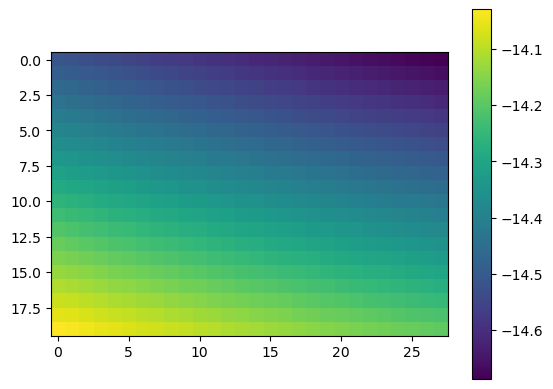

In [36]:
plt.imshow(ve_pred)
plt.colorbar()

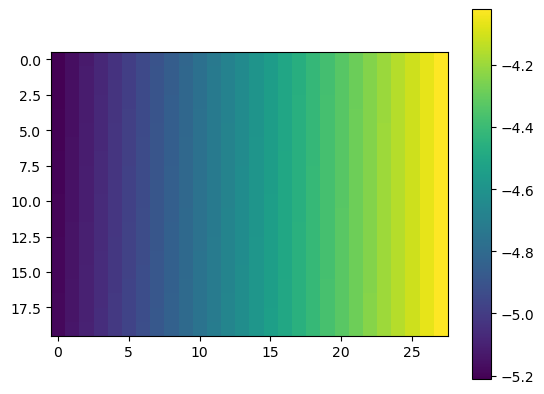

In [37]:
plt.imshow(vn_pred)
plt.colorbar()

In [38]:
get_model_per_frame(frame_id)

2025-09-30 10:27:44 | venti                | INFO     | Loading DISP frame database | taskName=Task-4 | message=Loading DISP frame database | asctime=2025-09-30 10:27:44
2025-09-30 10:27:44 | venti                | INFO     | Selected frame 3060 | taskName=Task-4 | message=Selected frame 3060 | asctime=2025-09-30 10:27:44
2025-09-30 10:27:44 | venti                | INFO     | Projected to EPSG:32614 for grid generation | taskName=Task-4 | message=Projected to EPSG:32614 for grid generation | asctime=2025-09-30 10:27:44
2025-09-30 10:27:44 | venti                | INFO     | Bounds: 230731, 4095471, 513608, 4299276 | taskName=Task-4 | message=Bounds: 230731, 4095471, 513608, 4299276 | asctime=2025-09-30 10:27:44
2025-09-30 10:27:44 | venti                | INFO     | Grid dimensions: 28 x 20 points | taskName=Task-4 | message=Grid dimensions: 28 x 20 points | asctime=2025-09-30 10:27:44
2025-09-30 10:27:44 | venti                | INFO     | Generated grid with 560 points | taskName=Ta

In [39]:
#!/usr/bin/env python3
"""Short script to load a 3-band GeoTIFF file."""

import rasterio
import numpy as np
import matplotlib.pyplot as plt

def load_geotiff(file_path):
    """Load and display info about a 3-band GeoTIFF file.
    
    Args:
        file_path: Path to the GeoTIFF file.
    
    Returns:
        tuple: (data_array, metadata)
    """
    with rasterio.open(file_path) as src:
        # Read all bands
        data = src.read()  # Shape: (bands, height, width)
        
        # Print basic info
        print(f"File: {file_path}")
        print(f"Shape: {data.shape}")
        print(f"Bands: {src.count}")
        print(f"CRS: {src.crs}")
        print(f"Transform: {src.transform}")
        print(f"Data type: {data.dtype}")
        print(f"NoData value: {src.nodata}")
        
        # Get metadata
        metadata = src.meta.copy()
        
        # Optional: Read individual bands
        band1 = src.read(1)  # North-South (mm/yr)
        band2 = src.read(2)  # East-West (mm/yr) 
        band3 = src.read(3)  # VLM (mm/yr)
        
        return data, metadata, (band1, band2, band3)

def plot_bands(data, titles=None):
    """Plot the three bands side by side.
    
    Args:
        data: 3D array (bands, height, width) or tuple of 2D arrays.
        titles: List of titles for each band.
    """
    if isinstance(data, tuple):
        bands = data
    else:
        bands = (data[0], data[1], data[2])
    
    if titles is None:
        titles = ['Band 1', 'Band 2', 'Band 3']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, (band, title) in enumerate(zip(bands, titles)):
        im = axes[i].imshow(band, cmap='RdBu_r')
        axes[i].set_title(title)
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i], shrink=0.7)
    
    plt.tight_layout()
    plt.show()


In [40]:
model_rates = load_geotiff('/u/aurora-r0/govorcin/01_OPERA/VLM/Venti/scripts/output/frame_3060_NOAM_ITRF2014_GIA_CARON_rates.tif')

File: /u/aurora-r0/govorcin/01_OPERA/VLM/Venti/scripts/output/frame_3060_NOAM_ITRF2014_GIA_CARON_rates.tif
Shape: (3, 6794, 9430)
Bands: 3
CRS: EPSG:32614
Transform: | 30.00, 0.00, 230731.28|
| 0.00,-30.00, 4299275.98|
| 0.00, 0.00, 1.00|
Data type: float32
NoData value: nan


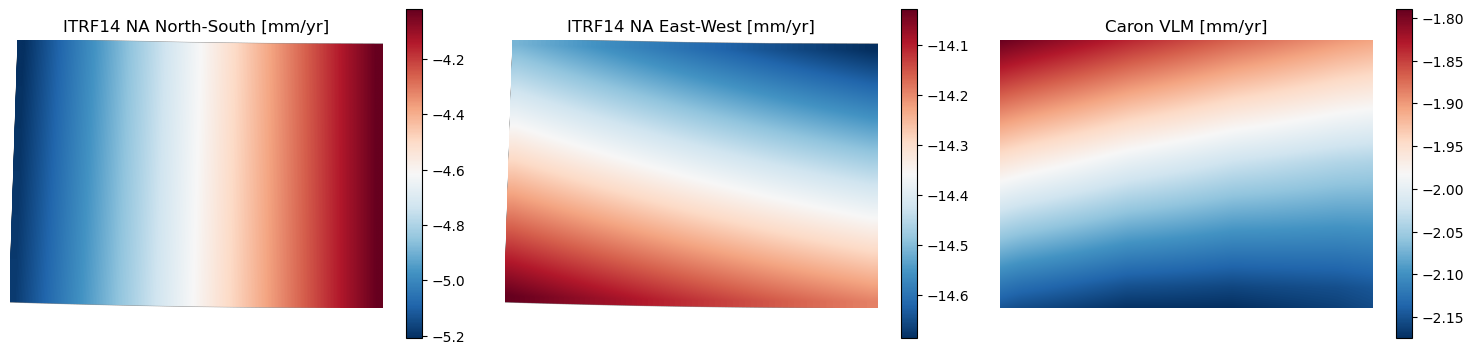

In [41]:
plot_bands(model_rates[0], ['ITRF14 NA North-South [mm/yr]', 'ITRF14 NA East-West [mm/yr]', 'Caron VLM [mm/yr]'])